In [16]:
import os, random, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10


DATASET_DIR = "chest-xray-pneumonia/versions/2"

print("TensorFlow:", tf.__version__)
print("Dataset directory:", DATASET_DIR)


TensorFlow: 2.21.0
Dataset directory: chest-xray-pneumonia/versions/2


In [3]:
extensions = ("*.jpeg", "*.jpg", "*.png")

image_paths = []
for ext in extensions:
    image_paths.extend(glob.glob(os.path.join(DATASET_DIR, "**", ext), recursive=True))

image_paths = sorted(image_paths)

if not image_paths:
    raise FileNotFoundError(
        "No images found. Download/extract the Chest X-Ray Images dataset "
        "and update DATASET_DIR."
    )

def get_label(path):
    parent = Path(path).parent.name.upper()
    if parent in ["NORMAL", "PNEUMONIA"]:
        return parent
    # Fallback: infer from path text
    return "PNEUMONIA" if "PNEUMONIA" in path.upper() else "NORMAL"

df = pd.DataFrame({
    "path": image_paths,
    "label": [get_label(p) for p in image_paths]
})

df = df[df["label"].isin(["NORMAL", "PNEUMONIA"])].reset_index(drop=True)
df = df[:1000]
print("Total images:", len(df))
print("\nImages per class:")
print(df["label"].value_counts())


Total images: 1000

Images per class:
label
NORMAL       610
PNEUMONIA    390
Name: count, dtype: int64


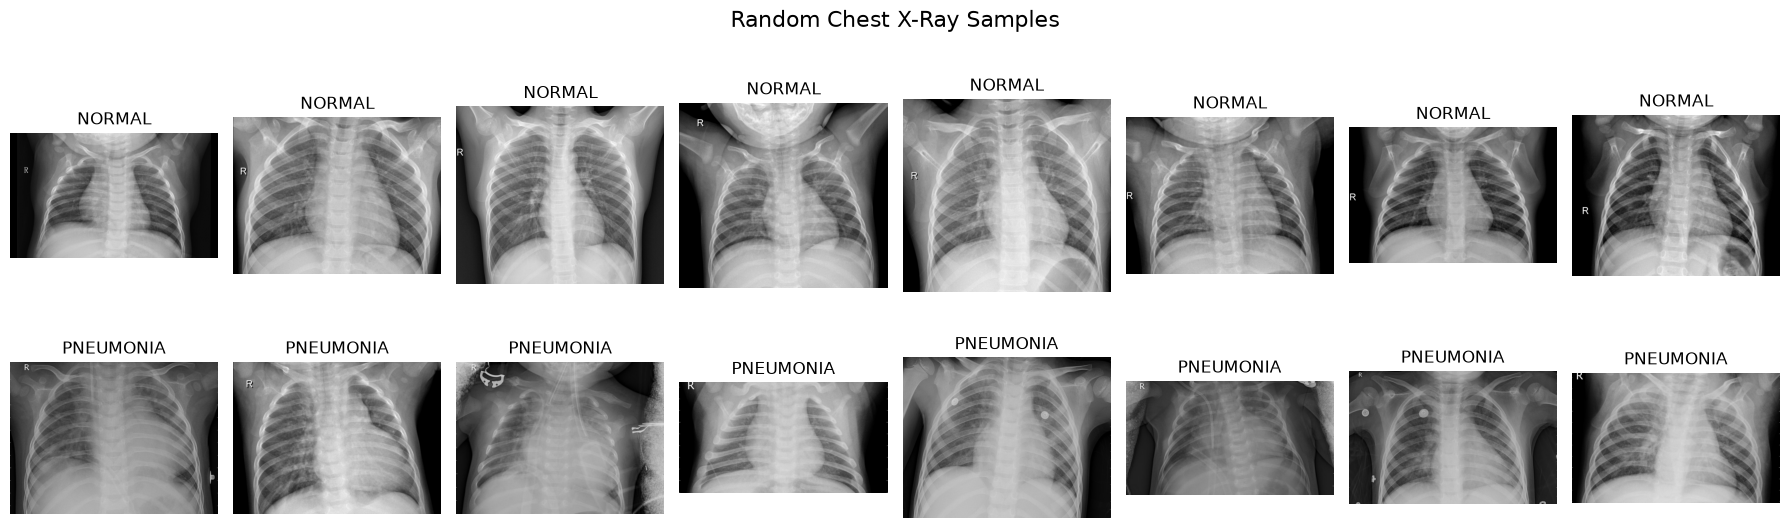

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(18, 6))

for row, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    samples = df[df["label"] == cls].sample(
        n=min(8, len(df[df["label"] == cls])),
        random_state=SEED
    )
    for col, (_, r) in enumerate(samples.iterrows()):
        img = Image.open(r["path"]).convert("L")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

    for col in range(len(samples), 8):
        axes[row, col].axis("off")

plt.suptitle("Random Chest X-Ray Samples", fontsize=16)
plt.tight_layout()
plt.show()


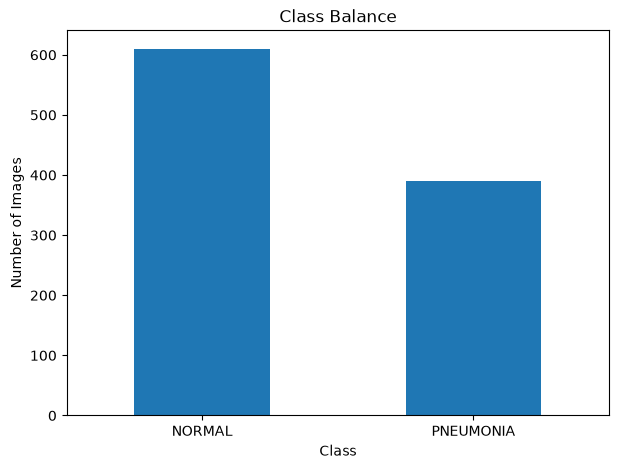

label
NORMAL       610
PNEUMONIA    390
Name: count, dtype: int64


In [5]:
class_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
class_counts.plot(kind="bar")
plt.title("Class Balance")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

print(class_counts)


In [6]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print("Train:", len(train_df), f"({len(train_df)/len(df):.1%})")
print("Validation:", len(val_df), f"({len(val_df)/len(df):.1%})")
print("Test:", len(test_df), f"({len(test_df)/len(df):.1%})")


Train: 700 (70.0%)
Validation: 150 (15.0%)
Test: 150 (15.0%)


In [7]:
def load_images(dataframe, img_size=IMG_SIZE):
    X, y = [], []
    for _, row in dataframe.iterrows():
        img = Image.open(row["path"]).convert("L")
        img = img.resize(img_size)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        X.append(arr)
        y.append(1 if row["label"] == "PNEUMONIA" else 0)

    X = np.expand_dims(np.array(X), axis=-1)
    y = np.array(y, dtype=np.int32)
    return X, y

X_train, y_train = load_images(train_df)
X_val, y_val = load_images(val_df)
X_test, y_test = load_images(test_df)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


X_train: (700, 128, 128, 1)
X_val: (150, 128, 128, 1)
X_test: (150, 128, 128, 1)


In [8]:
def extract_hog(img):
    return hog(
        img,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

def extract_lbp(img):
    # 8 neighbors, radius 1; histogram is a compact feature vector.
    lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
    n_bins = 10
    hist, _ = np.histogram(
        lbp.ravel(), bins=np.arange(0, n_bins + 1), range=(0, n_bins)
    )
    hist = hist.astype(np.float32)
    hist /= (hist.sum() + 1e-8)
    return hist

def extract_glcm(img):
    # Convert normalized grayscale image to 8-bit gray levels.
    img8 = (img * 255).astype(np.uint8)
    # Quantize to reduce GLCM size.
    img_q = (img8 // 32).astype(np.uint8)  # 8 gray levels
    glcm = graycomatrix(
        img_q,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=8,
        symmetric=True,
        normed=True
    )
    props = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
    return np.array([graycoprops(glcm, p).mean() for p in props], dtype=np.float32)

def extract_features(X):
    hog_features, lbp_features, glcm_features = [], [], []
    for img in X:
        gray = img.squeeze()
        hog_features.append(extract_hog(gray))
        lbp_features.append(extract_lbp(gray))
        glcm_features.append(extract_glcm(gray))
    return (
        np.array(hog_features),
        np.array(lbp_features),
        np.array(glcm_features)
    )

hog_train, lbp_train, glcm_train = extract_features(X_train)
hog_val, lbp_val, glcm_val = extract_features(X_val)
hog_test, lbp_test, glcm_test = extract_features(X_test)

print("HOG:", hog_train.shape)
print("LBP:", lbp_train.shape)
print("GLCM:", glcm_train.shape)


/home/lakshya/Programming/CSET343/.venv/lib/python3.12/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


HOG: (700, 1764)
LBP: (700, 10)
GLCM: (700, 5)


In [9]:
def build_cnn(filters=32, dropout=0.30, learning_rate=1e-3):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 1)),

        layers.Conv2D(filters, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(filters * 2, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(filters * 4, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_cnn()
model.summary()


E0000 00:00:1790530521.155132  218154 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,233 (16.35 MB)

 Trainable params: 4,287,233 (16.35 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 439ms/step - accuracy: 0.6186 - loss: 0.6626 - val_accuracy: 0.6067 - val_loss: 0.5811
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 419ms/step - accuracy: 0.7700 - loss: 0.4504 - val_accuracy: 0.9067 - val_loss: 0.2422
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 416ms/step - accuracy: 0.8786 - loss: 0.2879 - val_accuracy: 0.9400 - val_loss: 0.1877
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 418ms/step - accuracy: 0.8843 - loss: 0.2640 - val_accuracy: 0.9000 - val_loss: 0.3161
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 412ms/step - accuracy: 0.9271 - loss: 0.2091 - val_accuracy: 0.9400 - val_loss: 0.1531
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 414ms/step - accuracy: 0.9243 - loss: 0.1863 - val_accuracy: 0.9533 - val_loss: 0.1004
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 430ms/step - accuracy: 0.9171 - loss: 0.1960 - val_accuracy: 0.9733 - val_loss: 0.1221
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 418ms/step - accuracy: 0.9329 - loss: 0.1628 - val_accuracy: 0

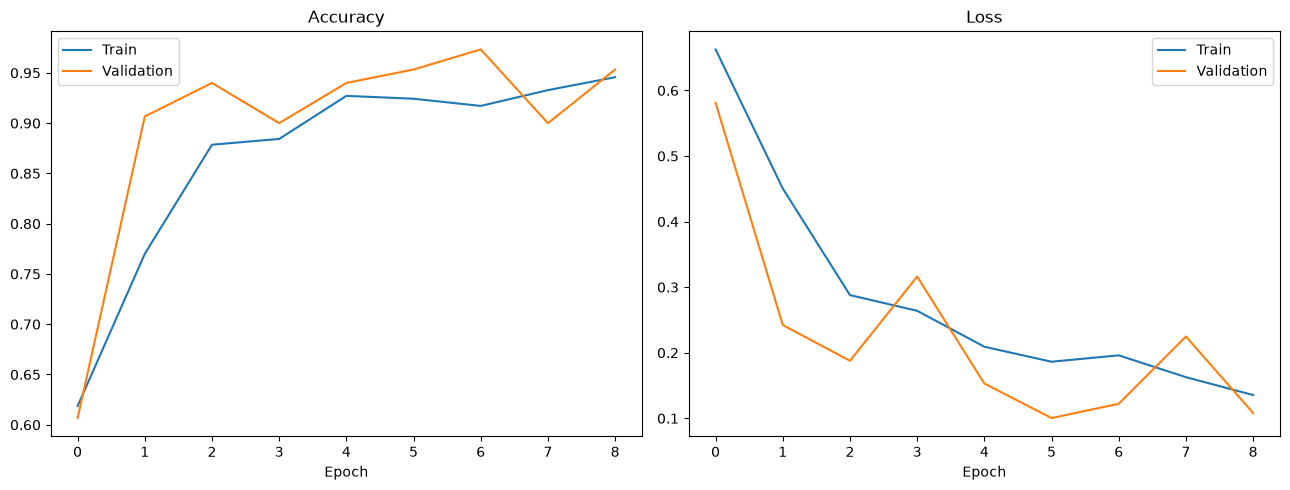

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(history.history["accuracy"], label="Train")
ax[0].plot(history.history["val_accuracy"], label="Validation")
ax[0].set_title("Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(history.history["loss"], label="Train")
ax[1].plot(history.history["val_loss"], label="Validation")
ax[1].set_title("Loss")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()


In [12]:
def evaluate_model(model, X, y, split_name="Test"):
    probabilities = model.predict(X, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    metrics = {
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(y, predictions, zero_division=0),
        "Recall": recall_score(y, predictions, zero_division=0),
        "F1-score": f1_score(y, predictions, zero_division=0),
        "AUROC": roc_auc_score(y, probabilities)
    }

    print(f"--- {split_name} metrics ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(classification_report(
        y, predictions, target_names=["NORMAL", "PNEUMONIA"], zero_division=0
    ))

    return metrics, probabilities, predictions

test_metrics, test_prob, test_pred = evaluate_model(
    model, X_test, y_test, "Test"
)


--- Test metrics ---
Accuracy: 0.9133
Precision: 0.9245
Recall: 0.8448
F1-score: 0.8829
AUROC: 0.9685

Classification report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.96      0.93        92
   PNEUMONIA       0.92      0.84      0.88        58

    accuracy                           0.91       150
   macro avg       0.92      0.90      0.91       150
weighted avg       0.91      0.91      0.91       150



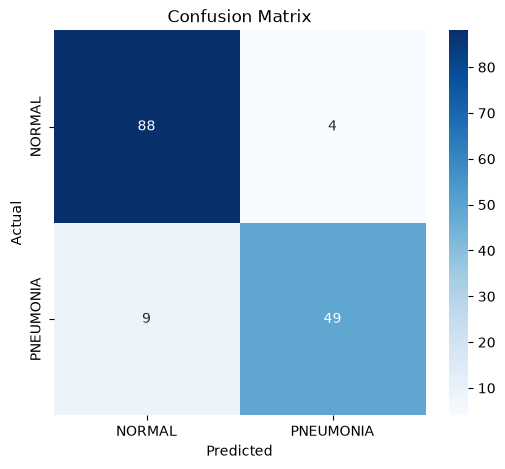

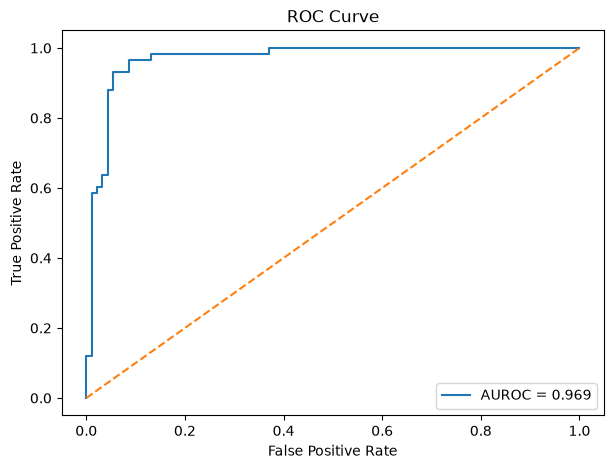

In [13]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_prob)
auc = roc_auc_score(y_test, test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


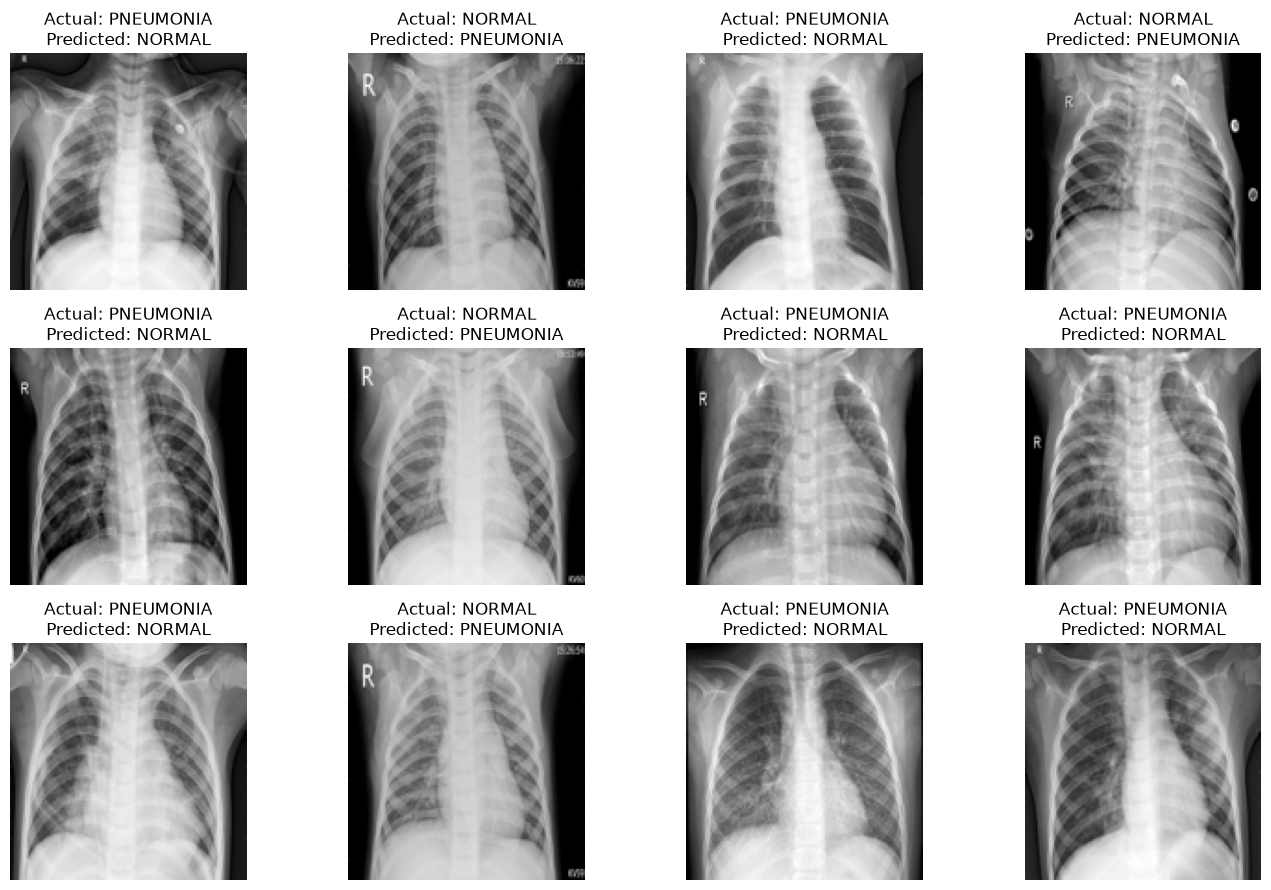

In [14]:
wrong_idx = np.where(test_pred != y_test)[0]

n_show = min(12, len(wrong_idx))
if n_show > 0:
    selected = wrong_idx[:n_show]
    cols = 4
    rows = int(np.ceil(n_show / cols))

    plt.figure(figsize=(14, 3 * rows))
    for i, idx in enumerate(selected):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(X_test[idx].squeeze(), cmap="gray")
        actual = "PNEUMONIA" if y_test[idx] else "NORMAL"
        pred = "PNEUMONIA" if test_pred[idx] else "NORMAL"
        plt.title(f"Actual: {actual}\nPredicted: {pred}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified test images.")


In [15]:
configs = [
    {"filters": 16, "dropout": 0.30, "learning_rate": 1e-3},
    {"filters": 32, "dropout": 0.30, "learning_rate": 1e-3},
    {"filters": 32, "dropout": 0.50, "learning_rate": 1e-3},
    {"filters": 32, "dropout": 0.30, "learning_rate": 1e-4},
]

tuning_results = []

for i, cfg in enumerate(configs, 1):
    print(f"\nConfiguration {i}/{len(configs)}:", cfg)

    candidate = build_cnn(**cfg)
    candidate.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=BATCH_SIZE,
        callbacks=[callbacks.EarlyStopping(
            monitor="val_loss", patience=2, restore_best_weights=True
        )],
        verbose=0
    )

    val_metrics, _, _ = evaluate_model(
        candidate, X_val, y_val, f"Validation config {i}"
    )
    tuning_results.append({**cfg, **val_metrics})

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df.sort_values("AUROC", ascending=False))



Configuration 1/4: {'filters': 16, 'dropout': 0.3, 'learning_rate': 0.001}
--- Validation config 1 metrics ---
Accuracy: 0.9467
Precision: 0.9474
Recall: 0.9153
F1-score: 0.9310
AUROC: 0.9933

Classification report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.97      0.96        91
   PNEUMONIA       0.95      0.92      0.93        59

    accuracy                           0.95       150
   macro avg       0.95      0.94      0.94       150
weighted avg       0.95      0.95      0.95       150


Configuration 2/4: {'filters': 32, 'dropout': 0.3, 'learning_rate': 0.001}
--- Validation config 2 metrics ---
Accuracy: 0.9533
Precision: 0.9194
Recall: 0.9661
F1-score: 0.9421
AUROC: 0.9914

Classification report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.95      0.96        91
   PNEUMONIA       0.92      0.97      0.94        59

    accuracy                           0.95       150
   macro avg       0.

,filters,dropout,learning_rate,Accuracy,Precision,Recall,F1-score,AUROC
0,16,0.3,0.0010,0.946667,0.947368,0.915254,0.931034,0.993295
3,32,0.3,0.0001,0.940000,0.878788,0.983051,0.928000,0.992177
1,32,0.3,0.0010,0.953333,0.919355,0.966102,0.942149,0.991432
2,32,0.5,0.0010,0.946667,0.963636,0.898305,0.929825,0.991246
